In [1]:
import pandas as pd
df=pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [2]:
#At=>Temparature
#V=>Vacume
#Ap=>Pressure
#RH=>Humidity
#PE=>Produced Energy

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x=df.drop("PE",axis=1)
y=df["PE"].copy()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
scaler=StandardScaler()
x_s=scaler.fit_transform(x_train)
y_s=scaler.transform(x_test)

In [5]:
import torch
import torch.nn as nn
x_train_tensor=torch.tensor(x_s,dtype=torch.float32)
x_test_tensor=torch.tensor(y_s,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [6]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

In [7]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

# Deep Learning

In [8]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
            #output layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [9]:
model=ANN()
#loss
criterion=nn.MSELoss()
#optimizer
import torch.optim as optim
optimizer=optim.Adam(model.parameters())

In [12]:
#Training the ANN
best_val_loss=float("inf")
epochs=50
train_losses=[]
val_losses=[]
for epoch  in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)    
    #Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss.item()
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
    print(f"{epoch+1}/{epochs}=>train_loss={epoch_train_loss} and validation_loss={epoch_val_loss}")
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

1/50=>train_loss=155844.75364583332 and validation_loss=125866.72421875
2/50=>train_loss=93271.76726888021 and validation_loss=63316.03307291667
3/50=>train_loss=43052.87358398437 and validation_loss=28969.972005208332
4/50=>train_loss=23190.660274251302 and validation_loss=19507.853173828124
5/50=>train_loss=17779.00906575521 and validation_loss=15868.594124348958
6/50=>train_loss=14500.704248555501 and validation_loss=12756.968294270833
7/50=>train_loss=11535.379229736329 and validation_loss=9832.119685872396
8/50=>train_loss=8655.38192138672 and validation_loss=7187.556266276041
9/50=>train_loss=6203.579579671224 and validation_loss=5018.316194661458
10/50=>train_loss=4247.808625284831 and validation_loss=3371.7432189941405
11/50=>train_loss=2796.071457417806 and validation_loss=2163.972083536784
12/50=>train_loss=1767.279199473063 and validation_loss=1341.5838114420574
13/50=>train_loss=1086.8738899230957 and validation_loss=810.4462249755859
14/50=>train_loss=657.2159232457478 and

Text(0, 0.5, 'losses')

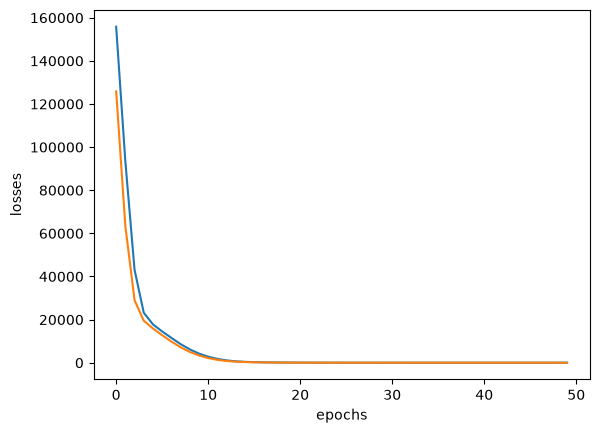

In [13]:
import matplotlib.pyplot as plt
df=pd.DataFrame({
    "train_loss":train_losses,
    "val_loss":val_losses
})
plt.plot(df["train_loss"],label="Training Loss")
plt.plot(df["val_loss"],label="Validation loss")
plt.xlabel("epochs")
plt.ylabel("losses")

In [14]:
#LOading our model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [17]:
#Evaluaton
model.eval()
with torch.no_grad():
    train_pred=model(x_train_tensor)
    val_pred=model(x_test_tensor)
    train_mse_loss=criterion(train_pred,y_train_tensor)
    val_mse_loss=criterion(val_pred,y_test_tensor)
    print("Training Mean Squred Error:",train_mse_loss.item())
    print("Testing Mean square Error:",val_mse_loss.item())

Training Mean Squred Error: 20.54973793029785
Testing Mean square Error: 18.769092559814453


In [18]:
from sklearn.metrics import r2_score
print("R2_score:",r2_score(y_test,val_pred))

R2_score: 0.9344068638168588


In [23]:
fir=pd.DataFrame(val_pred.numpy(),columns=["Test prediction"])
sec=pd.DataFrame(y_test.values,columns=["Actual prediction"])
pd.concat([fir,sec],axis=1)

,Test prediction,Actual prediction
0,434.924835,433.27
1,436.680206,438.16
2,461.476105,458.42
3,476.572174,480.82
4,435.047211,441.41
...,...,...
1909,451.327057,456.70
1910,431.339630,438.04
1911,467.469513,467.80
1912,430.747955,437.14
